# Part 2b — Thread scaling (speedup)

**Speedup** compares wall-clock runtime of the single-thread baseline to parallel runs:
\[ \text{Speedup}(n) = \frac{T_1}{T_n} \]

`T₁` / `Tₙ` are read from the **`real`** line of the `time` output in each `part2_b_results/*_Nthreads.txt` log. The **x-axis** is thread count **1, 2, 4, 8**. Run the code cell below (from repo root or from `pilots/`).


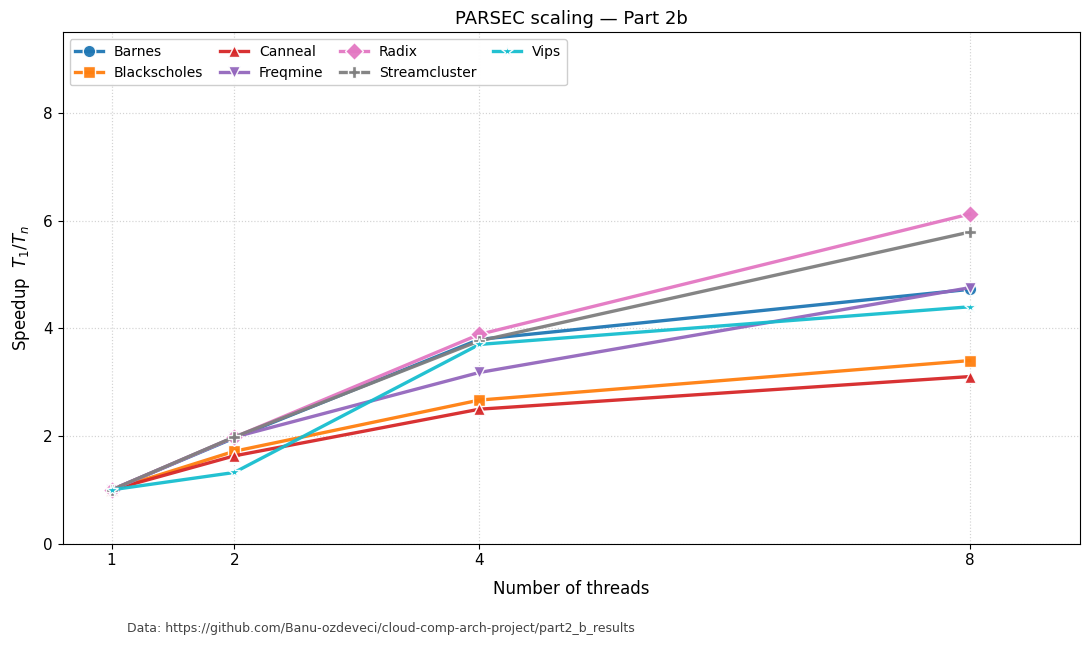

Results directory: /Users/banu/Desktop/cloud-comp-arch-project/part2_b_results
Workloads plotted: barnes, blackscholes, canneal, freqmine, radix, streamcluster, vips


In [7]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def resolve_results_dir() -> Path:
    here = Path.cwd().resolve()
    for base in (here, here.parent):
        cand = base / "part2_b_results"
        if cand.is_dir() and (cand / "barnes_1threads.txt").exists():
            return cand
    raise FileNotFoundError(
        "part2_b_results not found — run Jupyter from repo root or from pilots/, "
        "or place part2_b_results next to those directories."
    )


RESULT_DIR = resolve_results_dir()
THREAD_COUNTS = [1, 2, 4, 8]
_pat = re.compile(r"^(?P<wl>.+)_(?P<n>\d+)threads\.txt$")


def parse_real_seconds(log_text: str) -> float:
    for line in log_text.splitlines():
        if line.startswith("real"):
            m = re.search(r"(\d+)m([\d.]+)s", line)
            if m:
                return int(m.group(1)) * 60.0 + float(m.group(2))
    raise ValueError("No 'real' XmY.ZZs line found")


def discover_workloads() -> list[str]:
    workloads: set[str] = set()
    for p in RESULT_DIR.glob("*_*threads.txt"):
        m = _pat.match(p.name)
        if m:
            workloads.add(m.group("wl"))
    return sorted(workloads)


def workload_times_seconds(wl: str) -> dict[int, float]:
    out: dict[int, float] = {}
    for n in THREAD_COUNTS:
        path = RESULT_DIR / f"{wl}_{n}threads.txt"
        out[n] = parse_real_seconds(path.read_text())
    return out


workloads = discover_workloads()
series: dict[str, tuple[list[int], list[float]]] = {}
times_by_workload: dict[str, dict[int, float]] = {}
for wl in workloads:
    t = workload_times_seconds(wl)
    times_by_workload[wl] = dict(t)
    t1 = t[1]
    xs, ys = [], []
    for n in THREAD_COUNTS:
        xs.append(n)
        ys.append(t1 / t[n])
    series[wl] = (xs, ys)

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = plt.cm.tab10(np.linspace(0, 0.9, max(len(series), 1)))

nwl = len(workloads)
_dodge = 0.0001  # tiny x-shift per series — separates stacked markers at the same nominal thread count
xs_nominal = np.array(THREAD_COUNTS, dtype=float)
offsets: dict[str, float] = {}
for i, wl in enumerate(workloads):
    offsets[wl] = 0.0 if nwl <= 1 else ((i / (nwl - 1)) - 0.5) * _dodge

marker_cycle = ["o", "s", "^", "v", "D", "P", "*", "X"][:max(nwl, 1)]

for i, wl in enumerate(workloads):
    _, ys = series[wl]
    xplot = xs_nominal + offsets[wl]
    label = wl.replace("_", " ").title()
    ax.plot(
        xplot,
        ys,
        marker=marker_cycle[i % len(marker_cycle)],
        markersize=9,
        linewidth=2.4,
        color=colors[i],
        label=label,
        markeredgecolor="white",
        markeredgewidth=1,
        clip_on=False,
        alpha=0.95,
    )

ax.set_xticks(THREAD_COUNTS)
ax.set_xticklabels([str(n) for n in THREAD_COUNTS])
ax.set_xlim(0.6 - _dodge / 2, 8.9 + _dodge / 2)
ymax = float(max(max(ys_) for xs_, ys_ in series.values()))
ax.set_ylim(0, max(9.5, ymax * 1.12))

ax.set_xlabel("Number of threads", fontsize=12, labelpad=8)
ax.set_ylabel("Speedup  $T_1 / T_n$", fontsize=12, labelpad=8)
ax.set_title("PARSEC scaling — Part 2b", fontsize=13)

ax.tick_params(axis="both", labelsize=11)
ax.grid(True, linestyle=":", alpha=0.55, linewidth=0.85)
ax.set_axisbelow(True)
ax.legend(
    ncol=4,
    loc="upper left",
    framealpha=0.96,
    fontsize=10,
    columnspacing=1.2,
)

fig.text(
    0.12,
    0.02,
    f"Data: https://github.com/Banu-ozdeveci/cloud-comp-arch-project/part2_b_results",
    fontsize=9,
    color="#444",
)

fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

print("Results directory:", RESULT_DIR)
print("Workloads plotted:", ", ".join(workloads))


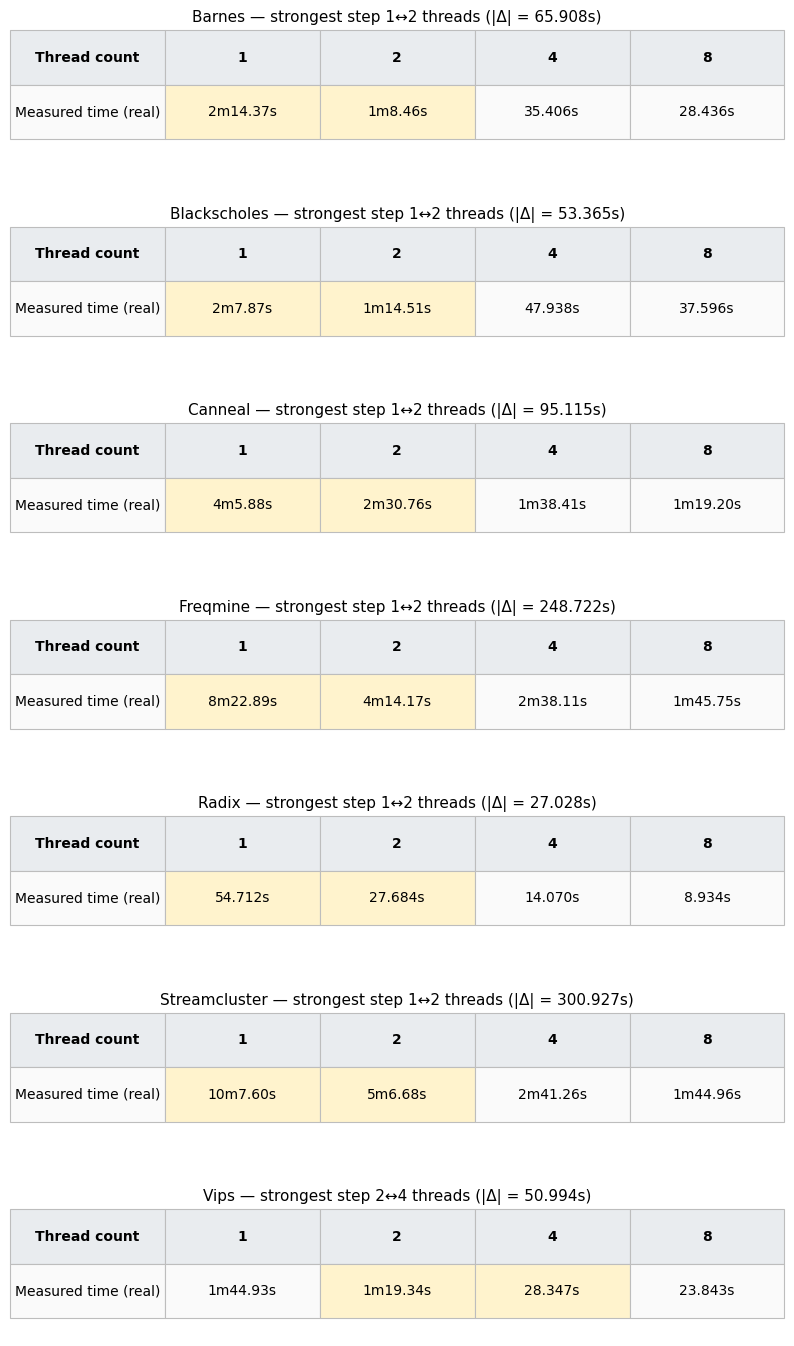

Each subplot is one workload table; amber pairs mark the consecutive step with the biggest absolute runtime change across 1→2→4→8 threads.


In [8]:
# Wall-clock runtime per workload (GNU `time`, `real`).
# Amber highlights the consecutive step (1→2, 2→4, 4→8) with largest |Δruntime|.

import matplotlib.pyplot as plt
import numpy as np

HIGHLIGHT = "#fff3cd"
HEADER_FACE = "#e9ecef"


def fmt_real(sec: float) -> str:
    m_i = int(sec // 60)
    s_rest = sec - 60 * m_i
    if m_i:
        return f"{m_i}m{s_rest:.2f}s"
    return f"{s_rest:.3f}s"


fig_h = max(3.8, len(workloads) * 2.05)
fig, axes = plt.subplots(len(workloads), 1, figsize=(8.8, fig_h))
axes_arr = np.atleast_1d(axes)

for idx, wl in enumerate(workloads):
    ax = axes_arr[idx]
    ax.axis("off")

    title = wl.replace("_", " ").title()
    tt = times_by_workload[wl]
    vals = np.array([float(tt[n]) for n in THREAD_COUNTS], dtype=float)
    step_diffs = np.abs(vals[:-1] - vals[1:])
    step_idx = int(np.argmax(step_diffs))
    n_lo, n_hi = THREAD_COUNTS[step_idx], THREAD_COUNTS[step_idx + 1]

    data = [
        ["Thread count", *[str(n) for n in THREAD_COUNTS]],
        ["Measured time (real)", *[fmt_real(float(tt[n])) for n in THREAD_COUNTS]],
    ]

    subtitle = (
        f"{title} — strongest step {n_lo}↔{n_hi} threads (|Δ| = {step_diffs[step_idx]:.3f}s)"
    )

    tbl = ax.table(
        cellText=data,
        loc="center",
        cellLoc="center",
        bbox=[0, 0.14, 1, 0.86],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.05, 2.1)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0.8)
        cell.set_edgecolor("#bdbdbd")
        if r == 0:
            cell.set_facecolor(HEADER_FACE)
            cell.set_text_props(weight="600")
        elif r == 1:
            cell.set_facecolor("#fafafa")
            if c >= 1:
                th = THREAD_COUNTS[c - 1]
                if th in {n_lo, n_hi}:
                    cell.set_facecolor(HIGHLIGHT)

    ax.set_title(subtitle, fontsize=11, pad=6)

fig.subplots_adjust(top=0.97, bottom=0.06, left=0.08, right=0.96, hspace=0.55)
plt.show()

print(
    "Each subplot is one workload table; amber pairs mark the consecutive step "
    "with the biggest absolute runtime change across 1→2→4→8 threads."
)
